# Team 14 - LendingClub P2P Loan Default Prediction

**Course:** UE24CS352A - Machine Learning  
**Problem No.:** 39  
**Team:** Karan Varshney (PES2UG24CS903) and D Sai Karthik (PES2UG24CS141)

## Problem statement
Peer-to-peer lending platforms must estimate whether a borrower is likely to repay a loan. In this project, we use historical LendingClub data to build machine-learning models that predict whether a finalized loan was **Fully Paid** or ended in **Default / Charged Off**.

The supplied reference paper also studies profitability, so after the default-classification task we add a second stage that predicts **Net Annualized Return (NAR)** and tests a simple loan-selection strategy.

## What this notebook covers
1. Dataset loading and filtering
2. Data cleaning and exploratory analysis
3. Feature engineering and leakage prevention
4. Logistic Regression, MLP and Random Forest classification
5. Validation-based threshold selection and final test evaluation
6. NAR regression using Linear, Ridge, MLP and Random Forest models
7. Loan-selection simulation
8. Final live demo and summary

The notebook is written so that the code used for the review is the same code used to generate the reported results.


## Submission alignment
The mini-project requires source code in a private GitHub repository with a README, a concise PDF write-up, a presentation and a live demonstration. This notebook is the main implementation file. The final result tables and plots produced here can be reused directly in the write-up and presentation.

**Important:** run the notebook from top to bottom before the final review so all output cells contain your actual results.


## 1. Setup and dataset download

The archive is large, so it is downloaded once with `kagglehub`. Only the accepted-loan file is used.

In [1]:
!pip -q install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print(path)
print(os.listdir(path))

100%|██████████| 1.26G/1.26G [00:18<00:00, 71.6MB/s]


Extracting files...
/root/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3
['accepted_2007_to_2018q4.csv', 'rejected_2007_to_2018Q4.csv.gz', 'accepted_2007_to_2018Q4.csv.gz', 'rejected_2007_to_2018q4.csv']


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42

## 2. Load the required columns

The full LendingClub file has many columns. We load only fields that are useful for the classification/regression tasks, plus the two fields needed later to calculate return.

### Main fields used
- `loan_amnt`, `funded_amnt`, `installment`: loan size and repayment amount
- `int_rate`, `grade`, `sub_grade`: LendingClub credit-risk information
- `annual_inc`, `dti`, `home_ownership`: borrower financial information
- `fico_range_low`, `fico_range_high`: credit-score range
- `delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `revol_util`: credit-behaviour variables
- `term`, `emp_length`, `purpose`, `addr_state`: loan/borrower characteristics
- `total_pymnt`, `last_pymnt_d`: used **only** to construct the profitability target, never as classifier inputs


In [3]:
file_path = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")

cols = [
    "loan_amnt",
    "funded_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "emp_title",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "issue_d",
    "loan_status",
    "purpose",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "fico_range_low",
    "fico_range_high",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "initial_list_status",
    "application_type",
    "mort_acc",
    "pub_rec_bankruptcies",
    "total_pymnt",
    "last_pymnt_d"
]

The file is read in chunks so that Colab does not have to keep the entire 2007-2018 dataset in memory. We keep only 2012-2015 loans with a final status.

In [4]:
final_status = ["Fully Paid", "Charged Off", "Default"]

parts = []

for chunk in pd.read_csv(
    file_path,
    usecols=cols,
    chunksize=100000,
    low_memory=False
):
    chunk["issue_d"] = pd.to_datetime(
        chunk["issue_d"],
        format="%b-%Y",
        errors="coerce"
    )

    chunk = chunk[
        chunk["issue_d"].dt.year.between(2012, 2015) &
        chunk["loan_status"].isin(final_status)
    ]

    parts.append(chunk)

df = pd.concat(parts, ignore_index=True)

df.shape

(786820, 33)

In [6]:
print(df.shape)
display(df.head())
df.info()

(786820, 33)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,total_pymnt,last_pymnt_d,application_type,mort_acc,pub_rec_bankruptcies
0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,Fully Paid,debt_consolidation,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,4421.723917,Jan-2019,Individual,1.0,0.0
1,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,Fully Paid,small_business,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,25679.660000,Jun-2016,Individual,4.0,0.0
2,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,Fully Paid,home_improvement,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,w,22705.924294,Jun-2017,Joint App,5.0,0.0
3,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,3 years,MORTGAGE,104433.0,Source Verified,2015-12-01,Fully Paid,major_purchase,PA,25.37,1.0,Jun-1998,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,11740.500000,Jul-2016,Individual,6.0,0.0
4,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,4 years,RENT,34000.0,Source Verified,2015-12-01,Fully Paid,debt_consolidation,GA,10.20,0.0,Oct-1987,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,13708.948530,May-2017,Individual,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786820 entries, 0 to 786819
Data columns (total 33 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   loan_amnt             786820 non-null  float64       
 1   funded_amnt           786820 non-null  float64       
 2   term                  786820 non-null  object        
 3   int_rate              786820 non-null  float64       
 4   installment           786820 non-null  float64       
 5   grade                 786820 non-null  object        
 6   sub_grade             786820 non-null  object        
 7   emp_title             740224 non-null  object        
 8   emp_length            745321 non-null  object        
 9   home_ownership        786820 non-null  object        
 10  annual_inc            786820 non-null  float64       
 11  verification_status   786820 non-null  object        
 12  issue_d               786820 non-null  datetime64[ns]
 13 

## 3. Define the classification target

`Fully Paid` is class 1. `Charged Off` and `Default` are class 0. Current or late loans were already removed because their final outcome is unknown.

In [8]:
print(df["loan_status"].value_counts())
print()
print(df["loan_status"].value_counts(normalize=True).mul(100).round(2))

,proportion
loan_status,
Fully Paid,81.36
Charged Off,18.64
Default,0.00


In [10]:
df["target"] = df["loan_status"].map({
    "Fully Paid": 1,
    "Charged Off": 0,
    "Default": 0
})

print(df["target"].value_counts())
print()
print(df["target"].value_counts(normalize=True).mul(100).round(2))

,proportion
target,
1,81.36
0,18.64


In [11]:
df["outcome"] = df["target"].map({
    1: "Fully Paid",
    0: "Default"
})

df[["loan_status", "target", "outcome"]].head(10)

,loan_status,target,outcome
0,Fully Paid,1,Fully Paid
1,Fully Paid,1,Fully Paid
2,Fully Paid,1,Fully Paid
3,Fully Paid,1,Fully Paid
4,Fully Paid,1,Fully Paid
5,Fully Paid,1,Fully Paid
6,Fully Paid,1,Fully Paid
7,Fully Paid,1,Fully Paid
8,Fully Paid,1,Fully Paid
9,Fully Paid,1,Fully Paid


In [12]:
print("Rows:", len(df))
print("Columns:", df.shape[1])
print()
print(df["issue_d"].dt.year.value_counts().sort_index())
print()
print(df["outcome"].value_counts())
print()
print(df["outcome"].value_counts(normalize=True).mul(100).round(2))

Rows: 786820
Columns: 35

issue_d
2012     53367
2013    134804
2014    223103
2015    375546
Name: count, dtype: int64

outcome
Fully Paid    640186
Default       146634
Name: count, dtype: int64

outcome
Fully Paid    81.36
Default       18.64
Name: proportion, dtype: float64


### Dataset check
The reference paper reported 745,529 finalized loans with roughly 81% positive and 19% negative examples. Our archived LendingClub file can contain a slightly different number of rows because it is a later snapshot. The important checks are that we use the same 2012-2015 period, remove unfinished loans and obtain a similar class distribution.


## 4. Basic cleaning and exploratory analysis

We first check missing values. `emp_title` is dropped because it is free-form text with a very large number of unique values. The paper also leaves free-form text analysis for future work.

In [13]:
missing = pd.DataFrame({
    "missing": df.isnull().sum(),
    "percent": df.isnull().mean().mul(100).round(2)
})

missing[missing["missing"] > 0].sort_values("percent", ascending=False)

,missing,percent
emp_title,46596,5.92
emp_length,41499,5.27
mort_acc,7495,0.95
last_pymnt_d,587,0.07
revol_util,394,0.05
dti,2,0.00


In [ ]:
missing_plot = missing[missing["percent"] > 0].sort_values("percent", ascending=False).head(15)
missing_plot["percent"].sort_values().plot(kind="barh", figsize=(8, 5), title="Top Missing-Value Percentages")
plt.xlabel("Missing values (%)")
plt.show()


In [14]:
# Free-form job titles create too many one-hot encoded columns.
df = df.drop(columns=["emp_title"])

A few raw fields are converted into simpler numerical features: term length in months, employment length in years, and the midpoint of the FICO range.

In [15]:
df["term_months"] = (
    df["term"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["emp_length_num"] = (
    df["emp_length"]
    .replace({
        "< 1 year": "0",
        "10+ years": "10"
    })
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["fico_score"] = (
    df["fico_range_low"] + df["fico_range_high"]
) / 2

### Outcome distribution

This plot shows the class imbalance in the data. Most loans are fully paid, so accuracy alone will not be enough to judge a classifier.

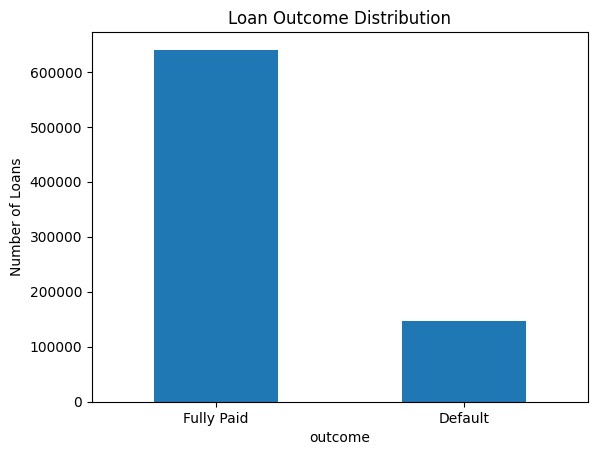

In [16]:
df["outcome"].value_counts().plot(
    kind="bar",
    title="Loan Outcome Distribution"
)

plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.show()

### Default rate by loan grade and term

These plots are useful sanity checks. Loan grade and loan term should show meaningful differences in repayment risk.

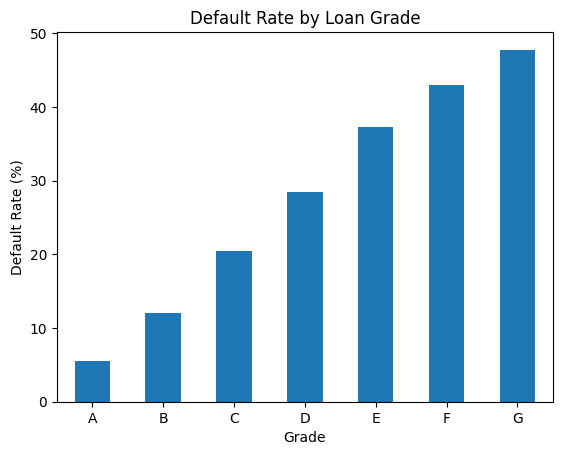

In [17]:
grade_default = (
    df.groupby("grade")["target"]
    .apply(lambda x: (1 - x).mean() * 100)
)

grade_default.plot(
    kind="bar",
    title="Default Rate by Loan Grade"
)

plt.ylabel("Default Rate (%)")
plt.xlabel("Grade")
plt.xticks(rotation=0)
plt.show()

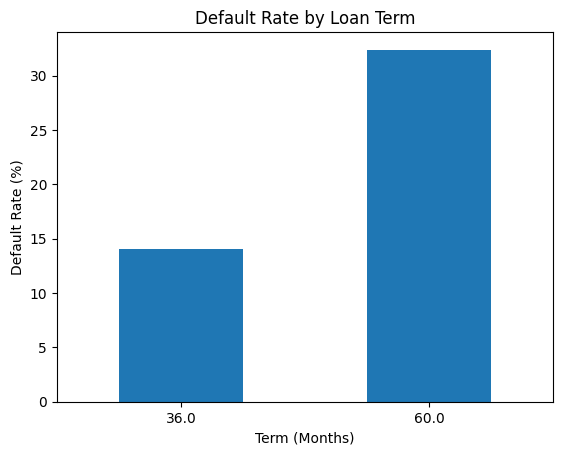

In [18]:
term_default = (
    df.groupby("term_months")["target"]
    .apply(lambda x: (1 - x).mean() * 100)
)

term_default.plot(
    kind="bar",
    title="Default Rate by Loan Term"
)

plt.ylabel("Default Rate (%)")
plt.xlabel("Term (Months)")
plt.xticks(rotation=0)
plt.show()

### Numerical features versus outcome

The following boxplots compare interest rate, debt-to-income ratio and FICO score for fully paid and defaulted loans.

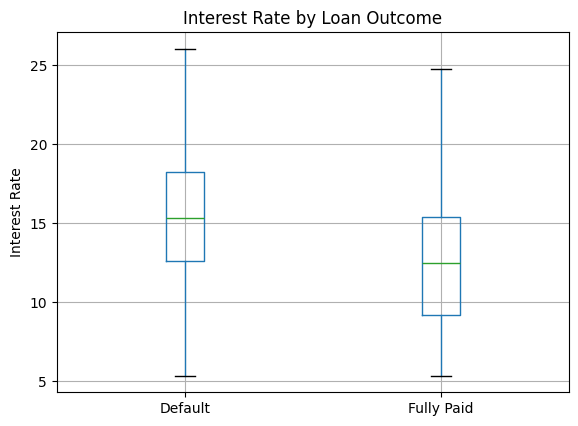

In [19]:
df.boxplot(
    column="int_rate",
    by="outcome",
    showfliers=False
)

plt.title("Interest Rate by Loan Outcome")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("Interest Rate")
plt.show()

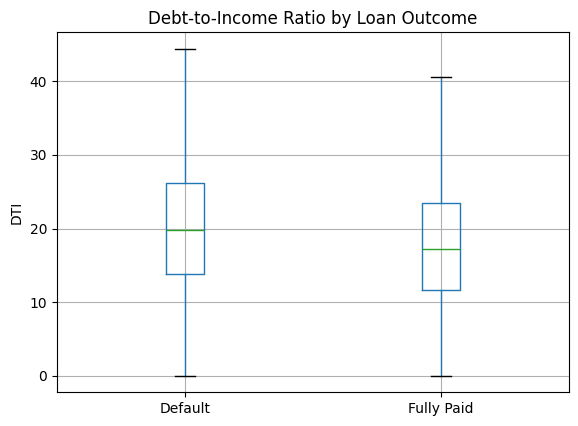

In [20]:
df.boxplot(
    column="dti",
    by="outcome",
    showfliers=False
)

plt.title("Debt-to-Income Ratio by Loan Outcome")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("DTI")
plt.show()

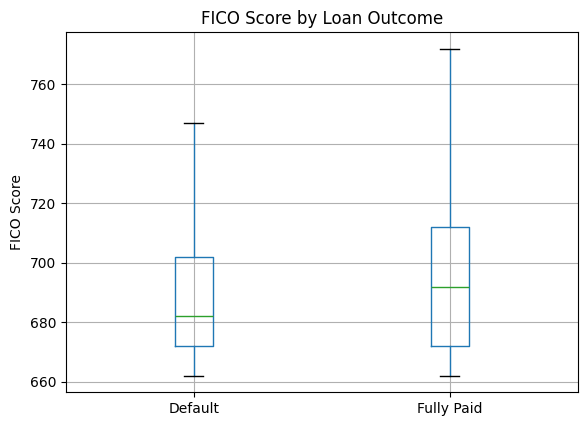

In [21]:
df.boxplot(
    column="fico_score",
    by="outcome",
    showfliers=False
)

plt.title("FICO Score by Loan Outcome")
plt.suptitle("")
plt.xlabel("")
plt.ylabel("FICO Score")
plt.show()

### Correlation among selected numerical features
The reference paper includes a numerical-feature correlation heatmap. We include a compact version here to identify strongly related variables before modelling.


In [ ]:
corr_cols = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_score", "open_acc", "revol_bal", "revol_util", "total_acc"
]

corr = df[corr_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=60, ha="right")
ax.set_yticklabels(corr_cols)
fig.colorbar(im, ax=ax, label="Correlation")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 5. Build the classifier feature matrix

### Leakage rule
For the default classifier, every input must be information that is available at or near loan origination. `total_pymnt` and `last_pymnt_d` describe what happened after the loan was issued, so using them would leak the answer into the model.

They are retained in the original dataframe only because the profitability section later needs them to calculate NAR. They are explicitly excluded from `X` below.


In [22]:
drop_classifier = [
    "loan_status",
    "target",
    "outcome",
    "total_pymnt",
    "last_pymnt_d",
    "term",
    "emp_length",
    "fico_range_low",
    "fico_range_high"
]

X = df.drop(columns=drop_classifier)
y = df["target"]

print(X.shape)
print(y.shape)
display(X.head())

(786820, 28)
(786820,)


,loan_amnt,funded_amnt,int_rate,installment,grade,sub_grade,home_ownership,annual_inc,verification_status,issue_d,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,term_months,emp_length_num,fico_score
0,3600.0,3600.0,13.99,123.03,C,C4,MORTGAGE,55000.0,Not Verified,2015-12-01,debt_consolidation,PA,5.91,0.0,Aug-2003,1.0,7.0,0.0,2765.0,29.7,13.0,w,Individual,1.0,0.0,36.0,10.0,677.0
1,24700.0,24700.0,11.99,820.28,C,C1,MORTGAGE,65000.0,Not Verified,2015-12-01,small_business,SD,16.06,1.0,Dec-1999,4.0,22.0,0.0,21470.0,19.2,38.0,w,Individual,4.0,0.0,36.0,10.0,717.0
2,20000.0,20000.0,10.78,432.66,B,B4,MORTGAGE,63000.0,Not Verified,2015-12-01,home_improvement,IL,10.78,0.0,Aug-2000,0.0,6.0,0.0,7869.0,56.2,18.0,w,Joint App,5.0,0.0,60.0,10.0,697.0
3,10400.0,10400.0,22.45,289.91,F,F1,MORTGAGE,104433.0,Source Verified,2015-12-01,major_purchase,PA,25.37,1.0,Jun-1998,3.0,12.0,0.0,21929.0,64.5,35.0,w,Individual,6.0,0.0,60.0,3.0,697.0
4,11950.0,11950.0,13.44,405.18,C,C3,RENT,34000.0,Source Verified,2015-12-01,debt_consolidation,GA,10.20,0.0,Oct-1987,0.0,5.0,0.0,8822.0,68.4,6.0,w,Individual,0.0,0.0,36.0,4.0,692.0


Before modelling, the date fields are converted into numerical information. Credit-history length is more useful than one-hot encoding every possible credit-start month.

In [23]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical:", len(categorical_cols))
print(categorical_cols)

Numeric: 18
['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'term_months', 'emp_length_num', 'fico_score']

Categorical: 10
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'earliest_cr_line', 'initial_list_status', 'application_type']


In [ ]:
X = X.copy()

X["issue_year"] = X["issue_d"].dt.year
X["issue_month"] = X["issue_d"].dt.month

X["earliest_cr_line"] = pd.to_datetime(
    X["earliest_cr_line"],
    format="%b-%Y",
    errors="coerce"
)

X["credit_history_years"] = (
    (X["issue_d"] - X["earliest_cr_line"]).dt.days / 365.25
)

X = X.drop(columns=["issue_d", "earliest_cr_line"])

In [ ]:
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical:", len(categorical_cols))
print(categorical_cols)

## 6. Train, validation and test split

70% of the data is used for training, 15% for validation and 15% for final testing. Stratification keeps the paid/default ratio almost identical in all three sets.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

In [ ]:
for name, values in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(name)
    print(values.value_counts(normalize=True).mul(100).round(2))
    print()

## 7. Preprocessing pipeline

Numerical columns use median imputation followed by standardization. Categorical columns use the most frequent value for missing data and one-hot encoding. Everything is kept inside a scikit-learn pipeline so preprocessing is learned only from training data.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def build_preprocessor():
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])

### Development mode

Tree ensembles and neural networks can take time on the full training set. Keep `FAST_MODE = True` while checking the notebook. For the final reported results, set it to `False` and run the modelling sections again.

In [ ]:
FAST_MODE = True
MODEL_SAMPLE_SIZE = 200000

if FAST_MODE and len(X_train) > MODEL_SAMPLE_SIZE:
    X_train_model, _, y_train_model, _ = train_test_split(
        X_train,
        y_train,
        train_size=MODEL_SAMPLE_SIZE,
        stratify=y_train,
        random_state=RANDOM_STATE
    )
else:
    X_train_model = X_train
    y_train_model = y_train

print("Model training rows:", len(X_train_model))

## Reference-paper classification benchmark
These are **paper results, not our results**. They are included only as a benchmark for discussion. Because our archived dataset and feature subset differ, exact replication is not expected.

| Model | Test Default F1 | Test Fully Paid F1 | Weighted performance |
|---|---:|---:|---:|
| Logistic Regression | 0.73 | 0.92 | about 0.88 |
| Neural Network | 0.72 | 0.93 | about 0.89 |
| Random Forest | 0.70 | 0.94 | about 0.89 |


## 8. Classification models

The reference paper compares Logistic Regression, a multilayer perceptron and Random Forest. A majority-class dummy model is added here as a baseline.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)


def classification_metrics(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    paid_prob = model.predict_proba(X_eval)[:, 1]
    default_prob = 1 - paid_prob
    y_default = 1 - y_eval.to_numpy()

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Default Precision": precision_score(y_eval, pred, pos_label=0, zero_division=0),
        "Default Recall": recall_score(y_eval, pred, pos_label=0, zero_division=0),
        "Default F1": f1_score(y_eval, pred, pos_label=0, zero_division=0),
        "Weighted F1": f1_score(y_eval, pred, average="weighted"),
        "ROC-AUC": roc_auc_score(y_default, default_prob),
        "PR-AUC": average_precision_score(y_default, default_prob)
    }

### 8.1 Dummy baseline

This model predicts the majority class every time. With an 81/19 class split it can still obtain high accuracy, which shows why recall, F1 and PR-AUC matter.

In [ ]:
dummy_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train_model, y_train_model)
dummy_result = classification_metrics("Dummy", dummy_model, X_val, y_val)

print(classification_report(
    y_val,
    dummy_model.predict(X_val),
    labels=[0, 1],
    target_names=["Default", "Fully Paid"],
    zero_division=0
))

### 8.2 Logistic Regression

Balanced class weights give more importance to the minority default class. This is close to the setup used in the paper.

In [ ]:
log_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=500,
        solver="saga",
        random_state=RANDOM_STATE
    ))
])

log_model.fit(X_train_model, y_train_model)
log_result = classification_metrics("Logistic Regression", log_model, X_val, y_val)

### 8.3 Neural Network

The hidden-layer sizes follow the reference paper. Early stopping is added so training stops when validation performance inside the training routine stops improving.

In [ ]:
mlp_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(10, 10, 5, 3),
        activation="logistic",
        solver="adam",
        batch_size=200,
        learning_rate_init=0.001,
        alpha=0.0001,
        max_iter=60,
        early_stopping=True,
        n_iter_no_change=5,
        random_state=RANDOM_STATE
    ))
])

mlp_model.fit(X_train_model, y_train_model)
mlp_result = classification_metrics("Neural Network", mlp_model, X_val, y_val)

### 8.4 Random Forest

The paper used 200 trees and considered at most 50 features at each split. `balanced_subsample` reweights classes separately for each bootstrap sample.

In [ ]:
rf_trees = 100 if FAST_MODE else 200

rf_model = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", RandomForestClassifier(
        n_estimators=rf_trees,
        max_features=50,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_model.fit(X_train_model, y_train_model)
rf_result = classification_metrics("Random Forest", rf_model, X_val, y_val)

### 8.5 Compare classification models
Accuracy alone is not enough because around four-fifths of the loans are fully paid. We therefore report default precision, default recall, default F1, weighted F1, ROC-AUC and PR-AUC.

For model selection we use **default-class F1 on the validation set**, because it balances how many defaults are detected against how many safe loans are incorrectly flagged.


In [ ]:
classification_results = pd.DataFrame([
    dummy_result,
    log_result,
    mlp_result,
    rf_result
]).set_index("Model")

classification_results.round(4)

In [ ]:
classification_results[["Default F1", "Default Recall", "Weighted F1"]].plot(
    kind="bar",
    figsize=(9, 5),
    title="Classification Model Comparison"
)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

## 9. Choose a classifier and tune the decision threshold

The best non-dummy model is chosen using validation default F1. The default-probability threshold is also selected on the validation set only. The test set remains untouched until the final evaluation.

In [ ]:
class_models = {
    "Logistic Regression": log_model,
    "Neural Network": mlp_model,
    "Random Forest": rf_model
}

best_classifier_name = (
    classification_results.drop(index="Dummy")
    .sort_values("Default F1", ascending=False)
    .index[0]
)
best_classifier = class_models[best_classifier_name]

val_default_prob = 1 - best_classifier.predict_proba(X_val)[:, 1]
y_val_default = 1 - y_val.to_numpy()

threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 81):
    pred_default = (val_default_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "f1": f1_score(y_val_default, pred_default),
        "precision": precision_score(y_val_default, pred_default, zero_division=0),
        "recall": recall_score(y_val_default, pred_default, zero_division=0)
    })

threshold_results = pd.DataFrame(threshold_rows)
best_threshold = threshold_results.loc[threshold_results["f1"].idxmax(), "threshold"]

print("Best classifier:", best_classifier_name)
print("Best default threshold:", round(best_threshold, 2))
threshold_results.sort_values("f1", ascending=False).head()

### Final classification result on the test set

In [ ]:
test_default_prob = 1 - best_classifier.predict_proba(X_test)[:, 1]
test_pred_default = (test_default_prob >= best_threshold).astype(int)
test_pred = 1 - test_pred_default

print(classification_report(
    y_test,
    test_pred,
    labels=[0, 1],
    target_names=["Default", "Fully Paid"],
    zero_division=0
))

print("Test ROC-AUC:", round(roc_auc_score(1 - y_test.to_numpy(), test_default_prob), 4))
print("Test PR-AUC:", round(average_precision_score(1 - y_test.to_numpy(), test_default_prob), 4))

In [ ]:
final_classification = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "Default Precision", "Default Recall", "Default F1", "Weighted F1"],
    "Value": [
        roc_auc_score(1 - y_test.to_numpy(), test_default_prob),
        average_precision_score(1 - y_test.to_numpy(), test_default_prob),
        precision_score(y_test, test_pred, pos_label=0, zero_division=0),
        recall_score(y_test, test_pred, pos_label=0, zero_division=0),
        f1_score(y_test, test_pred, pos_label=0, zero_division=0),
        f1_score(y_test, test_pred, average="weighted")
    ]
})
final_classification.round(4)


In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    display_labels=["Default", "Fully Paid"]
)
plt.title(f"{best_classifier_name} - Test Set")
plt.show()

In [ ]:
y_test_default = 1 - y_test.to_numpy()
fpr, tpr, _ = roc_curve(y_test_default, test_default_prob)
precision, recall, _ = precision_recall_curve(y_test_default, test_default_prob)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Default Detection")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Default Detection")
plt.show()

## 10. Random Forest feature importance

This gives a simple interpretation of which encoded features the Random Forest used most strongly. Importance does not prove causation; it only describes the fitted model.

In [ ]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_estimator = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
feature_importance = pd.Series(
    rf_estimator.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

feature_importance.head(15)

In [ ]:
feature_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Top Random Forest Features"
)
plt.xlabel("Importance")
plt.show()

# Part 2 - Profitability prediction

The classifier estimates repayment risk. The second part predicts net annualized return (NAR), which gives a more direct investment-oriented output.

## 11. Create the NAR regression target

The paper defines annualized return using loan amount, total payment and the time between issue and last payment. Payment information is used only to create the target, never as a predictor.

Because the public file stores month-level dates, this implementation is an approximation of the exact funding/payment-day calculation.

In [ ]:
reg_data = df[["loan_amnt", "total_pymnt", "issue_d", "last_pymnt_d"]].copy()
reg_data["last_pymnt_d"] = pd.to_datetime(
    reg_data["last_pymnt_d"],
    format="%b-%Y",
    errors="coerce"
)
reg_data["days_active"] = (reg_data["last_pymnt_d"] - reg_data["issue_d"]).dt.days

reg_data = reg_data[
    reg_data["loan_amnt"].gt(0) &
    reg_data["total_pymnt"].gt(0) &
    reg_data["days_active"].gt(0)
].copy()

payment_ratio = reg_data["total_pymnt"] / reg_data["loan_amnt"]
reg_data["nar"] = payment_ratio.pow(365 / reg_data["days_active"]) - 1
reg_data = reg_data[np.isfinite(reg_data["nar"])].copy()

reg_data["nar"].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])

A very small number of extreme annualized values can dominate squared-error regression. We trim only the outer 0.1% on each side and record the limits used.

In [ ]:
low_nar, high_nar = reg_data["nar"].quantile([0.001, 0.999])
reg_data = reg_data[reg_data["nar"].between(low_nar, high_nar)].copy()

print("NAR range used:", round(low_nar, 4), "to", round(high_nar, 4))
print("Regression rows:", len(reg_data))

In [ ]:
plt.figure(figsize=(7, 4))
plt.hist(reg_data["nar"], bins=80)
plt.xlabel("Net Annualized Return")
plt.ylabel("Number of Loans")
plt.title("NAR Distribution")
plt.show()

## 12. Regression train/validation/test split

The same pre-loan feature matrix `X` is used. Only rows with a valid NAR target are retained.

In [ ]:
X_reg = X.loc[reg_data.index].copy()
y_reg = reg_data["nar"].copy()

Xr_train, Xr_temp, yr_train, yr_temp = train_test_split(
    X_reg,
    y_reg,
    test_size=0.30,
    random_state=RANDOM_STATE
)

Xr_val, Xr_test, yr_val, yr_test = train_test_split(
    Xr_temp,
    yr_temp,
    test_size=0.50,
    random_state=RANDOM_STATE
)

if FAST_MODE and len(Xr_train) > MODEL_SAMPLE_SIZE:
    sample_index = Xr_train.sample(MODEL_SAMPLE_SIZE, random_state=RANDOM_STATE).index
    Xr_train_model = Xr_train.loc[sample_index]
    yr_train_model = yr_train.loc[sample_index]
else:
    Xr_train_model = Xr_train
    yr_train_model = yr_train

print("Train:", Xr_train.shape)
print("Validation:", Xr_val.shape)
print("Test:", Xr_test.shape)
print("Regression training rows used:", len(Xr_train_model))

## Reference-paper regression benchmark
Again, these values are from the supplied paper and are shown only for comparison.

| Model | Paper Test MSE | Paper Test R2 |
|---|---:|---:|
| Ridge Regression | 0.040 | 0.238 |
| Neural Network | 0.037 | 0.306 |
| Random Forest depth 4 | 0.037 | 0.295 |
| Random Forest depth 8 | 0.036 | 0.312 |
| Random Forest depth 10 | 0.036 | 0.315 |

The paper's best regressor was Random Forest with maximum depth 10.


## 13. Regression models

The paper compares Linear Regression, regularized linear regression, a neural network and Random Forest regression.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


def regression_metrics(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    mse = mean_squared_error(y_eval, pred)
    return {
        "Model": name,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_eval, pred)
    }

### 13.1 Linear Regression

In [ ]:
linear_reg = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", LinearRegression())
])

linear_reg.fit(Xr_train_model, yr_train_model)
linear_result = regression_metrics("Linear Regression", linear_reg, Xr_val, yr_val)

### 13.2 Ridge Regression

Ridge adds L2 regularization. It is useful when many encoded features are correlated or when ordinary linear regression becomes unstable.

In [ ]:
ridge_reg = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", Ridge(alpha=1.0))
])

ridge_reg.fit(Xr_train_model, yr_train_model)
ridge_result = regression_metrics("Ridge Regression", ridge_reg, Xr_val, yr_val)

### 13.3 Neural Network Regressor

The layer sizes follow the paper's regression network. ReLU is used for the hidden layers.

In [ ]:
mlp_reg = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(20, 10, 5, 3),
        activation="relu",
        solver="adam",
        batch_size=200,
        learning_rate_init=0.001,
        alpha=0.0001,
        max_iter=80,
        early_stopping=True,
        n_iter_no_change=5,
        random_state=RANDOM_STATE
    ))
])

mlp_reg.fit(Xr_train_model, yr_train_model)
mlp_reg_result = regression_metrics("Neural Network", mlp_reg, Xr_val, yr_val)

### 13.4 Random Forest Regressors
The paper explicitly compares tree-depth limits of 4, 8 and 10. We reproduce that comparison instead of training only one forest.


In [ ]:
rf_reg_trees = 60 if FAST_MODE else 120
rf_reg_results = []
rf_reg_models = {}

for depth in [4, 8, 10]:
    model = Pipeline([
        ("preprocessor", build_preprocessor()),
        ("model", RandomForestRegressor(
            n_estimators=rf_reg_trees,
            max_depth=depth,
            max_features=50,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])
    model.fit(Xr_train_model, yr_train_model)
    result = regression_metrics(f"Random Forest depth {depth}", model, Xr_val, yr_val)
    rf_reg_results.append(result)
    rf_reg_models[f"Random Forest depth {depth}"] = model

pd.DataFrame(rf_reg_results).set_index("Model").round(4)


### 13.5 Compare regression models

In [ ]:
regression_results = pd.DataFrame([
    linear_result,
    ridge_result,
    mlp_reg_result,
    *rf_reg_results
]).set_index("Model")

regression_results.round(4)


In [ ]:
regression_results[["R2"]].plot(
    kind="bar",
    figsize=(8, 4),
    legend=False,
    title="Regression Model Comparison"
)
plt.ylabel("Validation R2")
plt.xticks(rotation=20)
plt.show()

## 14. Final regression model and loan-selection strategy
The best regressor is selected using validation `R2`. We then rank validation loans by predicted NAR and choose a prediction threshold using **only the validation set**. That threshold is applied once to the untouched test set.

The supplied paper reported that a predicted-NAR threshold of about 0.132 selected roughly 1.7% of loans and produced about 15% mean annualized return in its test simulation. Our value can differ because the dataset snapshot and feature set are not identical.


In [ ]:
reg_models = {
    "Linear Regression": linear_reg,
    "Ridge Regression": ridge_reg,
    "Neural Network": mlp_reg,
    **rf_reg_models
}

best_regressor_name = regression_results.sort_values("R2", ascending=False).index[0]
best_regressor = reg_models[best_regressor_name]

val_nar_pred = best_regressor.predict(Xr_val)

candidate_thresholds = np.quantile(val_nar_pred, np.linspace(0.50, 0.99, 60))
strategy_rows = []

for threshold in np.unique(candidate_thresholds):
    selected = val_nar_pred >= threshold
    if selected.sum() < 500:
        continue
    strategy_rows.append({
        "threshold": threshold,
        "selected_loans": int(selected.sum()),
        "selected_percent": selected.mean() * 100,
        "actual_mean_nar": yr_val.to_numpy()[selected].mean()
    })

strategy_results = pd.DataFrame(strategy_rows)
best_strategy = strategy_results.loc[strategy_results["actual_mean_nar"].idxmax()]
investment_threshold = float(best_strategy["threshold"])

print("Best regressor:", best_regressor_name)
print("Validation threshold:", round(investment_threshold, 4))
print("Validation loans selected (%):", round(best_strategy["selected_percent"], 2))
print("Validation actual mean NAR:", round(best_strategy["actual_mean_nar"], 4))


### Final regression and investment result on the test set

In [ ]:
test_nar_pred = best_regressor.predict(Xr_test)

test_mse = mean_squared_error(yr_test, test_nar_pred)
print("Test MSE:", round(test_mse, 4))
print("Test RMSE:", round(np.sqrt(test_mse), 4))
print("Test R2:", round(r2_score(yr_test, test_nar_pred), 4))

test_selected = test_nar_pred >= investment_threshold
print("Loans selected:", int(test_selected.sum()))
print("Loans selected (%):", round(test_selected.mean() * 100, 2))
print("Mean NAR - all test loans:", round(yr_test.mean(), 4))
print("Mean NAR - selected loans:", round(yr_test.to_numpy()[test_selected].mean(), 4))

In [ ]:
final_regression = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R2", "Selection threshold", "Loans selected (%)", "All-loan mean NAR", "Selected-loan mean NAR"],
    "Value": [
        test_mse,
        np.sqrt(test_mse),
        r2_score(yr_test, test_nar_pred),
        investment_threshold,
        test_selected.mean() * 100,
        yr_test.mean(),
        yr_test.to_numpy()[test_selected].mean()
    ]
})
final_regression.round(4)


The following graph is similar to the paper's loan-selection plot. Loans are ranked by predicted NAR. The curve shows the actual mean NAR as progressively more loans are included.

In [ ]:
order = np.argsort(test_nar_pred)[::-1]
ordered_actual = yr_test.to_numpy()[order]

percentages = np.linspace(1, 100, 100)
mean_returns = []

for pct in percentages:
    count = max(1, int(len(ordered_actual) * pct / 100))
    mean_returns.append(ordered_actual[:count].mean())

plt.figure(figsize=(7, 4))
plt.plot(percentages, mean_returns)
plt.xlabel("Percentage of Loans Selected")
plt.ylabel("Actual Mean NAR")
plt.title("Investment Return vs Loans Selected")
plt.show()

# Part 3 - Live demonstration

For the review, use a real loan from the held-out regression test set. The classifier gives default probability, the regressor gives predicted NAR, and the final line applies the learned investment threshold.

In [ ]:
def demo_loan(position=0):
    idx = Xr_test.index[position]
    sample = X.loc[[idx]]

    paid_prob = best_classifier.predict_proba(sample)[0, 1]
    default_prob = 1 - paid_prob
    predicted_nar = best_regressor.predict(sample)[0]

    actual_outcome = "Fully Paid" if y.loc[idx] == 1 else "Default"
    actual_nar = y_reg.loc[idx]
    decision = "INVEST" if predicted_nar >= investment_threshold else "DO NOT INVEST"

    print("Loan index:", idx)
    print("Actual outcome:", actual_outcome)
    print("Actual NAR:", round(actual_nar, 4))
    print("Predicted default probability:", f"{default_prob * 100:.2f}%")
    print("Predicted NAR:", f"{predicted_nar * 100:.2f}%")
    print("Decision:", decision)

    display(sample[[
        "loan_amnt", "int_rate", "annual_inc", "dti",
        "fico_score", "term_months", "grade", "purpose"
    ]])


demo_loan(0)

### Optional custom-input demo

This starts from one valid test row so that every required field is present. Change a few values and rerun the prediction cell to show how the model response changes.

In [ ]:
custom_loan = Xr_test.iloc[[0]].copy()

custom_loan["loan_amnt"] = 20000
custom_loan["annual_inc"] = 60000
custom_loan["dti"] = 22
custom_loan["fico_score"] = 680
custom_loan["term_months"] = 60
custom_loan["int_rate"] = 16.5

paid_prob = best_classifier.predict_proba(custom_loan)[0, 1]
default_prob = 1 - paid_prob
predicted_nar = best_regressor.predict(custom_loan)[0]

decision = "INVEST" if predicted_nar >= investment_threshold else "DO NOT INVEST"

print("Predicted default probability:", f"{default_prob * 100:.2f}%")
print("Predicted NAR:", f"{predicted_nar * 100:.2f}%")
print("Decision:", decision)

# Final review summary
Run the cell below immediately before the demonstration. It collects the main results in one place so the evaluation panel can see the complete project outcome without searching through the notebook.


In [ ]:
print("TEAM 14 - FINAL SUMMARY")
print("=" * 32)
print("Dataset rows:", len(df))
print("Fully Paid (%):", round((df["target"] == 1).mean() * 100, 2))
print("Default/Charged Off (%):", round((df["target"] == 0).mean() * 100, 2))
print()
print("Best classifier:", best_classifier_name)
print("Decision threshold for default:", round(best_threshold, 2))
print("Test default F1:", round(f1_score(y_test, test_pred, pos_label=0), 4))
print("Test default recall:", round(recall_score(y_test, test_pred, pos_label=0), 4))
print("Test ROC-AUC:", round(roc_auc_score(1 - y_test.to_numpy(), test_default_prob), 4))
print()
print("Best regressor:", best_regressor_name)
print("Test R2:", round(r2_score(yr_test, test_nar_pred), 4))
print("Investment threshold:", round(investment_threshold, 4))
print("Loans selected (%):", round(test_selected.mean() * 100, 2))
print("Selected-loan mean NAR (%):", round(yr_test.to_numpy()[test_selected].mean() * 100, 2))


## 15. Save result tables

These CSV files are useful for the report and presentation. Trained models are not saved by default because Random Forest files can be large.

In [ ]:
classification_results.round(6).to_csv("classification_results.csv")
regression_results.round(6).to_csv("regression_results.csv")
threshold_results.to_csv("classification_thresholds.csv", index=False)
strategy_results.to_csv("investment_strategy_validation.csv", index=False)

print("Result tables saved.")

# Conclusion, limitations and submission notes

## Project flow
1. Load LendingClub accepted-loan data.
2. Keep finalized 2012-2015 loans only.
3. Define `Fully Paid = 1` and `Default/Charged Off = 0`.
4. Inspect missing values and class imbalance.
5. Engineer term, employment length, FICO and credit-history features.
6. Exclude post-loan variables from the classifier to prevent leakage.
7. Compare Logistic Regression, MLP and Random Forest against a dummy baseline.
8. Select the classifier and probability threshold using validation data only.
9. Evaluate once on the held-out test set.
10. Construct NAR and compare regression models, including Random Forest depths 4, 8 and 10.
11. Select an investment threshold on validation data and simulate it on the test set.
12. Demonstrate one held-out loan with predicted default probability, predicted return and the resulting decision.

## Limitations
- The LendingClub archive is a historical dataset; results do not automatically generalize to current lending markets.
- LendingClub's own grade and interest-rate fields already summarize part of the platform's risk assessment.
- NAR is an investment-oriented target built from historical repayment outcomes and does not represent guaranteed future returns.
- Our selected feature subset is smaller than the full 1,097-feature representation used in the reference paper.

## Future work
Possible extensions are time-based testing on later years, analysis of free-form loan descriptions, macroeconomic variables and more systematic hyperparameter tuning.

## Individual contribution
The course evaluates individual contribution. Before submission, replace this section with the **actual work done by each team member** (for example: data preparation/EDA, classification, regression, report, presentation and repository maintenance). Do not claim work that was not actually performed.
